<a href="https://colab.research.google.com/github/tanveera2001/world-model-indoor-scene-understanding/blob/main/World_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WORLD MODEL

### Real-Time Indoor Scene Understanding for Robotics

**Course:** CSE445 – Machine Learning  
**Group:** Group-13

**Group Members:**
- Md. Tanveer Ahmed — 2311582042
- S.M. Mahin — 2132140642
- Zidan Zafar Rudra — 2013747642
- Shameem Ahmed Rizwan — 2233704642


In [14]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Not available")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [15]:
!pip install -q ultralytics

In [16]:
from google.colab import files

uploaded = files.upload()

Saving CSE445_18classes.zip to CSE445_18classes (1).zip


In [17]:
# EXTRACT DATASET SAFELY

import zipfile
import os
import shutil

output = "/content/dataset_fixed"

if os.path.exists(output):
    shutil.rmtree(output)

with zipfile.ZipFile("/content/CSE445_18classes.zip") as z:
    for member in z.infolist():
        name = member.filename.replace("\\", "/")
        name = name.replace("CSE445_18classes/", "", 1)

        path = os.path.join(output, name)

        # SKIP DIRECTORY ENTRIES
        if name.endswith("/"):
            os.makedirs(path, exist_ok=True)
            continue

        os.makedirs(os.path.dirname(path), exist_ok=True)

        with z.open(member) as src, open(path, "wb") as dst:
            dst.write(src.read())

print("DATASET EXTRACTED SUCCESSFULLY")
print(os.listdir(output))

DATASET EXTRACTED SUCCESSFULLY
['valid', 'test', 'data.yaml', 'train']


In [18]:
# VERIFY DATASET IMAGE AND LABEL COUNTS

from pathlib import Path

root = Path("/content/dataset_fixed")

for split in ["train", "valid", "test"]:
    images = list((root / split / "images").glob("*"))
    labels = list((root / split / "labels").glob("*.txt"))

    print(f"{split.upper()}:")
    print(f"  Images: {len(images)}")
    print(f"  Labels: {len(labels)}")

TRAIN:
  Images: 131
  Labels: 131
VALID:
  Images: 34
  Labels: 34
TEST:
  Images: 17
  Labels: 17


In [19]:
# CREATE COLAB DATASET CONFIG

from pathlib import Path

yaml_content = """train: /content/dataset_fixed/train/images
val: /content/dataset_fixed/valid/images
test: /content/dataset_fixed/test/images

nc: 18
names: ['bed', 'chair', 'fan', 'door', 'table', 'sink', 'curtain', 'window', 'commode', 'mirror', 'sofa', 'bidet_shower', 'tap', 'shower', 'floor_drain', 'air_conditioner', 'toilet_paper_holder', 'toothbrush_holder']
"""

Path("/content/dataset_fixed/data_colab.yaml").write_text(yaml_content)

print("COLAB DATASET CONFIG CREATED")

COLAB DATASET CONFIG CREATED


In [20]:
# LOAD YOLO11N SEGMENTATION MODEL

from ultralytics import YOLO

model = YOLO("yolo11n-seg.pt")

print("YOLO11N SEGMENTATION MODEL LOADED")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
YOLO11N SEGMENTATION MODEL LOADED


In [21]:
# TRAIN YOLO11N SEGMENTATION BASELINE MODEL

results = model.train(
    data="/content/dataset_fixed/data_colab.yaml",
    epochs=100,
    imgsz=432,
    batch=16,
    device=0,
    patience=20,
    project="/content/runs",
    name="cse445_yolo11n_seg"
)

Ultralytics 8.4.141 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_fixed/data_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=432, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cse445_yolo11n_seg

In [22]:
# SHOW FINAL TRAINING RESULTS

print(results.results_dict)


{'metrics/precision(B)': 0.6639771352159844, 'metrics/recall(B)': 0.4802287249118147, 'metrics/mAP50(B)': 0.5241020100732169, 'metrics/mAP50-95(B)': 0.37733520477225524, 'metrics/precision(M)': 0.6917921894447455, 'metrics/recall(M)': 0.5188837289108431, 'metrics/mAP50(M)': 0.5488210981571757, 'metrics/mAP50-95(M)': 0.3350682504532146, 'fitness': 0.7124034552254699}


In [23]:
# EVALUATE MODEL ON TEST SET

test_results = model.val(
    data="/content/dataset_fixed/data_colab.yaml",
    split="test",
    imgsz=432,
    device=0
)

print(test_results.results_dict)

WARNING ⚠️ imgsz=[432] must be multiple of max stride 32, updating to [448]
Ultralytics 8.4.141 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg summary (fused): 113 layers, 2,838,078 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 420.2±116.6 MB/s, size: 22.3 KB)
val: Scanning /content/dataset_fixed/test/labels... 17 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17/17 1.1Kit/s 0.0s
val: New cache created: /content/dataset_fixed/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6it/s 1.2s
                   all         17         80       0.74      0.476      0.533      0.379      0.704      0.488      0.479      0.295
                   bed          5          6      0.463      0.833      0.538      0.266      0.425      0.833      0.538      0.283
                 chair          1          

In [24]:
# RUN PREDICTION ON TEST IMAGES

pred_results = model.predict(
    source="/content/dataset_fixed/test/images",
    imgsz=448,
    conf=0.25,
    save=True
)

print("PREDICTIONS COMPLETED")


image 1/17 /content/dataset_fixed/test/images/468216607_10234903308553524_5292090764458609417_n_jpg.rf.a2dbca19b8ac5d8a64d94fd8dee63259.jpg: 448x448 1 window, 15.1ms
image 2/17 /content/dataset_fixed/test/images/484226398_1058118223025660_6056868848850068075_n_jpg.rf.951d6540e34bce88131a113ec715b3df.jpg: 448x448 1 bed, 1 curtain, 13.5ms
image 3/17 /content/dataset_fixed/test/images/503415864_2894753027363552_1021280292334323482_n_jpg.rf.7b00489132999f3c605e88685019d51e.jpg: 448x448 1 door, 1 commode, 1 mirror, 1 floor_drain, 1 toilet_paper_holder, 1 toothbrush_holder, 9.7ms
image 4/17 /content/dataset_fixed/test/images/515135194_24484616081135052_4555697243026692082_n_jpg.rf.544ee5b074c2cde73ac8546c11e706b0.jpg: 448x448 3 doors, 2 windows, 10.9ms
image 5/17 /content/dataset_fixed/test/images/6323062604661723566_jpg.rf.5fe06308a97ec045f5eacec5d8ea0bbe.jpg: 448x448 3 beds, 1 window, 11.0ms
image 6/17 /content/dataset_fixed/test/images/6323062604661723571_jpg.rf.fd77f0dff996f45d254b45b6f

In [27]:
# LOAD BEST TRAINED MODEL

from ultralytics import YOLO

best_model = YOLO("/content/runs/cse445_yolo11n_seg/weights/best.pt")

print("BEST MODEL LOADED")

BEST MODEL LOADED


In [28]:
# RUN FINAL PREDICTIONS WITH BEST MODEL

best_model.predict(
    source="/content/dataset_fixed/test/images",
    imgsz=448,
    conf=0.25,
    save=True,
    project="/content/final_results",
    name="test_predictions"
)

print("FINAL PREDICTIONS SAVED")



image 1/17 /content/dataset_fixed/test/images/468216607_10234903308553524_5292090764458609417_n_jpg.rf.a2dbca19b8ac5d8a64d94fd8dee63259.jpg: 448x448 1 window, 14.7ms
image 2/17 /content/dataset_fixed/test/images/484226398_1058118223025660_6056868848850068075_n_jpg.rf.951d6540e34bce88131a113ec715b3df.jpg: 448x448 1 bed, 1 curtain, 9.2ms
image 3/17 /content/dataset_fixed/test/images/503415864_2894753027363552_1021280292334323482_n_jpg.rf.7b00489132999f3c605e88685019d51e.jpg: 448x448 1 door, 1 commode, 1 mirror, 1 floor_drain, 1 toilet_paper_holder, 1 toothbrush_holder, 9.3ms
image 4/17 /content/dataset_fixed/test/images/515135194_24484616081135052_4555697243026692082_n_jpg.rf.544ee5b074c2cde73ac8546c11e706b0.jpg: 448x448 3 doors, 2 windows, 14.4ms
image 5/17 /content/dataset_fixed/test/images/6323062604661723566_jpg.rf.5fe06308a97ec045f5eacec5d8ea0bbe.jpg: 448x448 3 beds, 1 window, 9.8ms
image 6/17 /content/dataset_fixed/test/images/6323062604661723571_jpg.rf.fd77f0dff996f45d254b45b6f0e

TOTAL RESULT IMAGES: 17


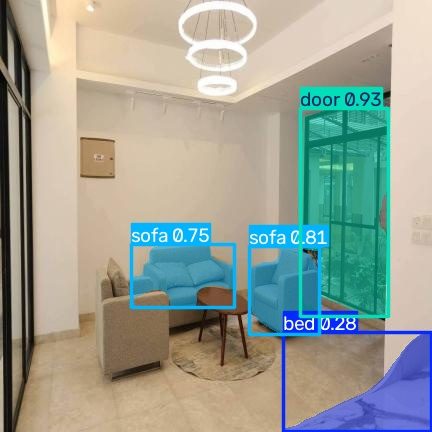

In [30]:
# DISPLAY FINAL PREDICTION RESULTS

from IPython.display import display
from PIL import Image
from pathlib import Path

result_dir = Path("/content/final_results/test_predictions")

images = list(result_dir.glob("*.jpg"))

print("TOTAL RESULT IMAGES:", len(images))

display(Image.open(images[1]))